#### Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("project_dataset.csv")

df.head()

,movie_id,title,Budget,Revenue,Popularity,Genres,Primary_Genre,Genre_Count,Director,Production_Companies,...,Release_Month,Release_Month_Name,Release_Quarter,Release_Season,Has_Budget_Data,Has_Revenue_Data,Has_Financial_Data,Has_Genre_Data,Has_Company_Data,Has_Release_Data
0,19995,Avatar,237000000.0,2.923706e+09,36.00,"Science Fiction, Action, Adventure",Science Fiction,3,James Cameron,"Dune Entertainment, Lightstorm Entertainment, ...",...,12.0,December,Q4,Winter,True,True,True,True,True,True
1,285,Pirates of the Caribbean: At World's End,300000000.0,9.616912e+08,17.81,"Adventure, Fantasy, Action",Adventure,3,Gore Verbinski,"Jerry Bruckheimer Films, Second Mate Productio...",...,5.0,May,Q2,Spring,True,True,True,True,True,True
2,206647,Spectre,245000000.0,8.807076e+08,9.26,"Action, Adventure, Thriller",Action,3,Sam Mendes,"Metro-Goldwyn-Mayer, Columbia Pictures, EON Pr...",...,10.0,October,Q4,Autumn,True,True,True,True,True,True
3,49026,The Dark Knight Rises,250000000.0,1.081041e+09,17.45,"Action, Crime, Drama, Thriller",Action,4,Christopher Nolan,"Syncopy, Legendary Pictures, Warner Bros. Pict...",...,7.0,July,Q3,Summer,True,True,True,True,True,True
4,49529,John Carter,263700000.0,2.841000e+08,8.93,"Action, Adventure, Science Fiction",Action,3,Andrew Stanton,Walt Disney Pictures,...,3.0,March,Q1,Spring,True,True,True,True,True,True


#### Dataset Information

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

df.info()

Shape: (4803, 51)

Columns:
['movie_id', 'title', 'Budget', 'Revenue', 'Popularity', 'Genres', 'Primary_Genre', 'Genre_Count', 'Director', 'Production_Companies', 'Primary_Production_Company', 'Production_Company_Count', 'Release_Date', 'Cast_Count', 'Lead_Actor', 'Second_Lead_Actor', 'Third_Lead_Actor', 'Male_Cast_Count', 'Female_Cast_Count', 'Unknown_Cast_Gender_Count', 'Cast_Gender_Ratio', 'Crew_Count', 'Producer_Count', 'Writer_Count', 'Male_Crew_Count', 'Female_Crew_Count', 'Unknown_Crew_Gender_Count', 'Unique_Department_Count', 'Top_Crew_Department', 'Cast_Crew_Ratio', 'Total_People_Involved', 'Profit', 'ROI', 'Revenue_Budget_Ratio', 'Budget_Category', 'Financial_Result', 'Budget_Efficiency', 'Popularity_Category', 'Profitability_Category', 'Popularity_Profitability_Segment', 'Release_Year', 'Release_Month', 'Release_Month_Name', 'Release_Quarter', 'Release_Season', 'Has_Budget_Data', 'Has_Revenue_Data', 'Has_Financial_Data', 'Has_Genre_Data', 'Has_Company_Data', 'Has_Release_Dat

#### Statistical Distribution

In [4]:
numeric_df = df.select_dtypes(include='number')

stats = numeric_df.describe().T

stats["Median"] = numeric_df.median()
stats["Variance"] = numeric_df.var()
stats["Skewness"] = numeric_df.skew()
stats["Kurtosis"] = numeric_df.kurt()

stats

,count,mean,std,min,25%,50%,75%,max,Median,Variance,Skewness,Kurtosis
movie_id,4803.0,5.716548e+04,8.869461e+04,5.000000e+00,9.014500e+03,14629.00,5.861050e+04,4.594880e+05,14629.00,7.866735e+09,2.072080,3.346748
Budget,4795.0,3.049464e+07,4.019944e+07,0.000000e+00,3.500000e+06,16000000.00,4.000000e+07,3.790000e+08,16000000.00,1.615995e+15,2.419978,7.532708
Revenue,4795.0,8.848475e+07,1.653167e+08,0.000000e+00,2.824471e+06,27645491.00,1.001023e+08,2.923706e+09,27645491.00,2.732962e+16,4.642384,38.167206
Popularity,4795.0,4.254229e+00,5.339444e+00,3.000000e-02,1.690000e+00,2.92,4.975000e+00,1.851900e+02,2.92,2.850966e+01,10.747387,287.584937
Genre_Count,4803.0,2.565064e+00,1.004200e+00,0.000000e+00,2.000000e+00,3.00,3.000000e+00,7.000000e+00,3.00,1.008417e+00,0.304606,0.062823
Production_Company_Count,4803.0,3.209452e+00,1.991407e+00,0.000000e+00,2.000000e+00,3.00,4.000000e+00,1.700000e+01,3.00,3.965700e+00,1.403004,3.824158
Cast_Count,4803.0,2.212305e+01,1.958249e+01,0.000000e+00,1.100000e+01,16.00,2.500000e+01,2.240000e+02,16.00,3.834740e+02,3.315525,17.296533
Male_Cast_Count,4803.0,1.005434e+01,7.942877e+00,0.000000e+00,5.000000e+00,8.00,1.300000e+01,8.800000e+01,8.00,6.308930e+01,2.486272,11.859439
Female_Cast_Count,4803.0,5.031855e+00,5.368746e+00,0.000000e+00,2.000000e+00,4.00,6.000000e+00,1.070000e+02,4.00,2.882343e+01,5.546131,61.899559
Unknown_Cast_Gender_Count,4803.0,7.036852e+00,1.117613e+01,0.000000e+00,1.000000e+00,4.00,8.000000e+00,1.640000e+02,4.00,1.249060e+02,4.453132,30.917776


#### Missing Values

In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
ROI,869,18.092859
Revenue_Budget_Ratio,869,18.092859
Profit,869,18.092859
Cast_Gender_Ratio,307,6.391838
Production_Companies,123,2.560899
Third_Lead_Actor,63,1.311680
Second_Lead_Actor,53,1.103477
Lead_Actor,43,0.895274
Director,30,0.624610
Genres,10,0.208203


#### Duplicate Values

In [6]:
print("Duplicate Rows :", df.duplicated().sum())

if "movie_id" in df.columns:
    print("Duplicate movie_id :", df["movie_id"].duplicated().sum())

Duplicate Rows : 0
Duplicate movie_id : 0


#### Pearson Correlation

In [7]:
numeric_df = df.select_dtypes(include='number')

pearson = numeric_df.corr(method="pearson")

pearson

,movie_id,Budget,Revenue,Popularity,Genre_Count,Production_Company_Count,Cast_Count,Male_Cast_Count,Female_Cast_Count,Unknown_Cast_Gender_Count,...,Female_Crew_Count,Unknown_Crew_Gender_Count,Unique_Department_Count,Cast_Crew_Ratio,Total_People_Involved,Profit,ROI,Revenue_Budget_Ratio,Release_Year,Release_Month
movie_id,1.000000,-0.095512,-0.058393,-0.114886,-0.120880,-0.015063,-0.011822,-0.146200,-0.039958,0.102385,...,-0.108125,0.026833,-0.131324,0.032082,-0.034986,0.029987,-0.011494,-0.011494,0.435088,-0.039129
Budget,-0.095512,1.000000,0.730124,0.402255,0.280629,0.121921,0.338627,0.440024,0.207382,0.180976,...,0.325075,0.401885,0.361255,-0.145678,0.488101,0.560980,-0.030888,-0.030888,0.173016,0.035258
Revenue,-0.058393,0.730124,1.000000,0.551301,0.170434,0.013594,0.380818,0.422703,0.226089,0.258228,...,0.282382,0.384391,0.325199,-0.117170,0.484988,0.980635,0.011275,0.011275,0.088364,0.044053
Popularity,-0.114886,0.402255,0.551301,1.000000,0.107106,0.020832,0.318232,0.358549,0.162531,0.224696,...,0.243824,0.318010,0.332811,-0.138514,0.411317,0.521029,0.003199,0.003199,-0.025260,0.051116
Genre_Count,-0.120880,0.280629,0.170434,0.107106,1.000000,0.093466,0.059844,0.128023,-0.007241,0.017349,...,0.048724,0.121667,0.149749,-0.082608,0.124562,0.103301,-0.022006,-0.022007,-0.016978,-0.028908
Production_Company_Count,-0.015063,0.121921,0.013594,0.020832,0.093466,1.000000,0.080348,0.072534,0.052259,0.064131,...,0.159709,0.158542,0.233218,-0.126178,0.161189,-0.060086,-0.018433,-0.018433,0.239109,0.016049
Cast_Count,-0.011822,0.338627,0.380818,0.318232,0.059844,0.080348,1.000000,0.780334,0.686574,0.867774,...,0.344252,0.290952,0.364250,0.144760,0.720211,0.331737,-0.023151,-0.023152,-0.015332,0.055829
Male_Cast_Count,-0.146200,0.440024,0.422703,0.358549,0.128023,0.072534,0.780334,1.000000,0.429508,0.450253,...,0.331752,0.329567,0.407526,0.048745,0.661705,0.346926,-0.031686,-0.031686,-0.108946,0.066948
Female_Cast_Count,-0.039958,0.207382,0.226089,0.162531,-0.007241,0.052259,0.686574,0.429508,1.000000,0.417367,...,0.378550,0.146449,0.239635,0.119576,0.472677,0.182191,-0.018842,-0.018842,0.067466,0.029007
Unknown_Cast_Gender_Count,0.102385,0.180976,0.258228,0.224696,0.017349,0.064131,0.867774,0.450253,0.417367,1.000000,...,0.185565,0.205223,0.233486,0.161561,0.564597,0.246620,-0.009242,-0.009242,0.018156,0.036306


#### Pearson Correlation Heatmap

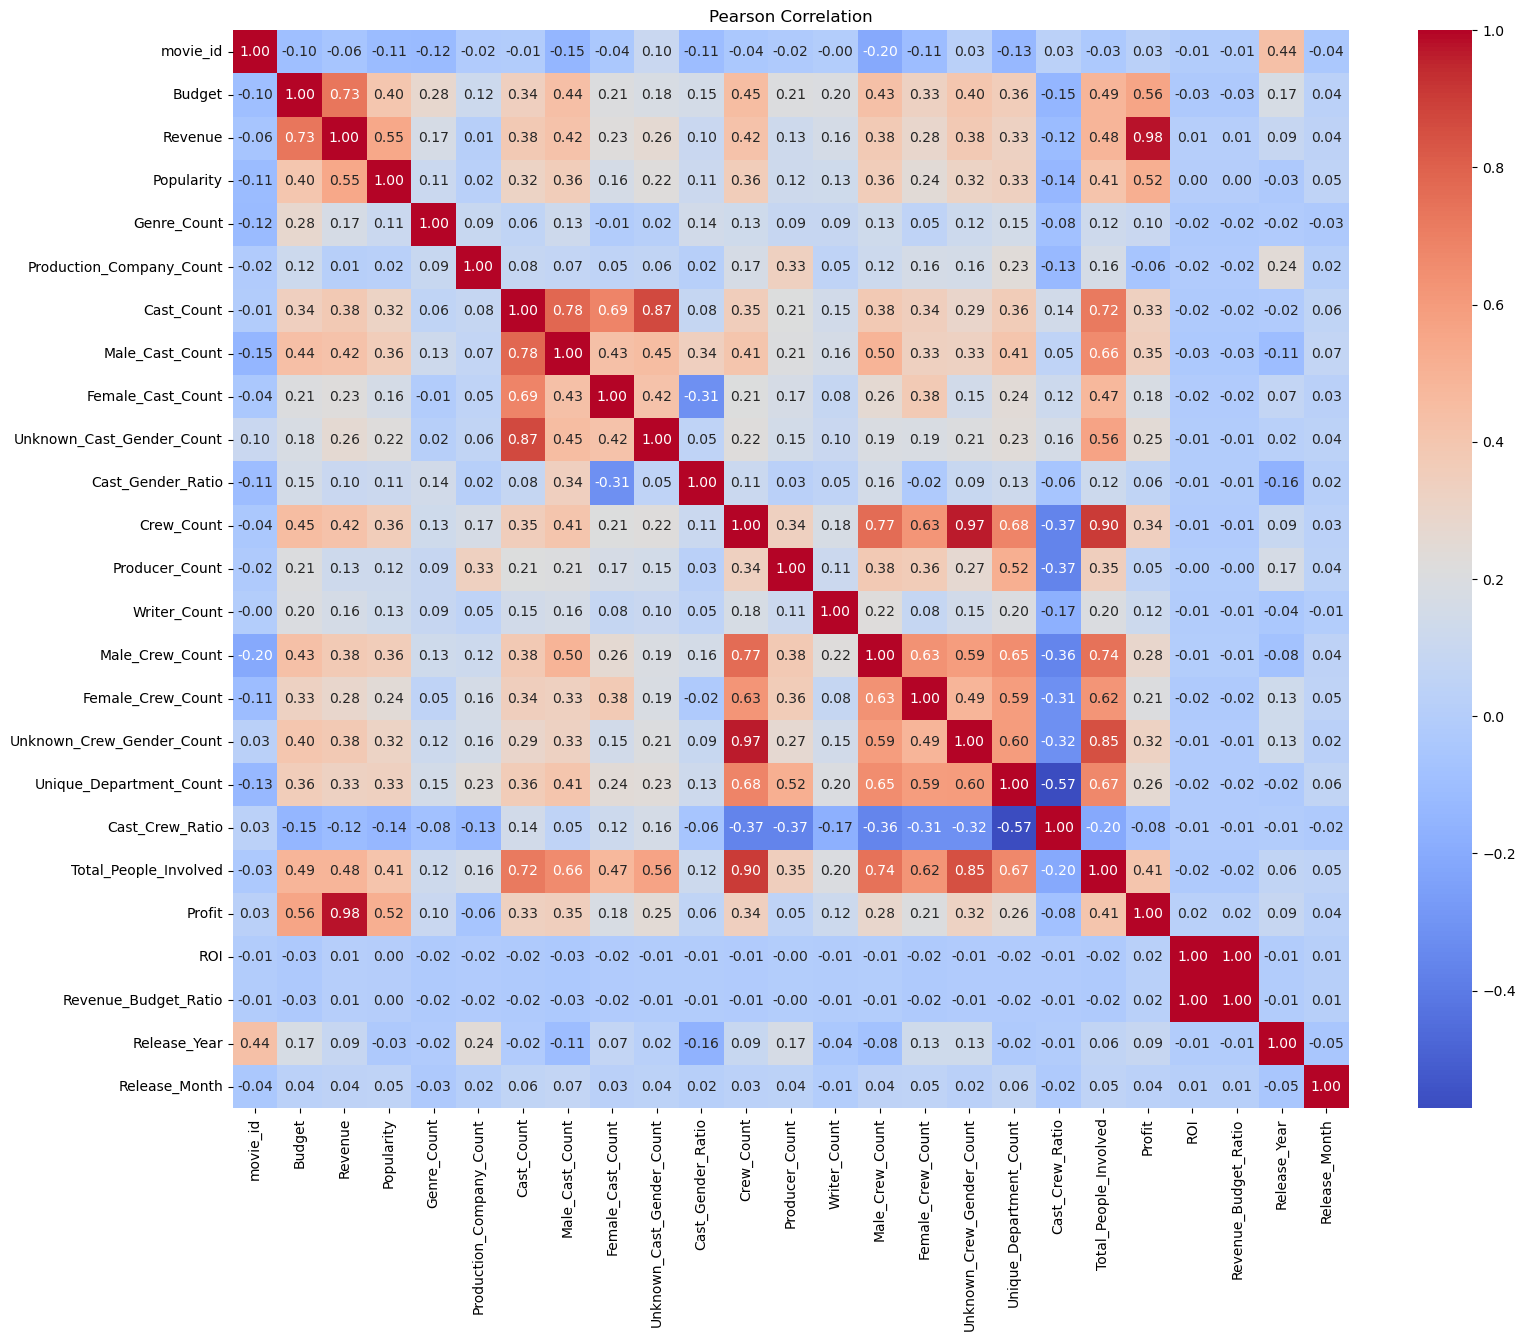

In [8]:
plt.figure(figsize=(18,14))

sns.heatmap(
    pearson,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Pearson Correlation")
plt.show()

#### Spearman Correlation

In [9]:
spearman = numeric_df.corr(method="spearman")

spearman

,movie_id,Budget,Revenue,Popularity,Genre_Count,Production_Company_Count,Cast_Count,Male_Cast_Count,Female_Cast_Count,Unknown_Cast_Gender_Count,...,Female_Crew_Count,Unknown_Crew_Gender_Count,Unique_Department_Count,Cast_Crew_Ratio,Total_People_Involved,Profit,ROI,Revenue_Budget_Ratio,Release_Year,Release_Month
movie_id,1.000000,-0.254743,-0.338530,-0.383478,-0.127295,-0.024782,-0.182857,-0.296164,-0.108303,0.032761,...,-0.231972,-0.073100,-0.253304,0.126724,-0.236497,-0.155962,-0.180528,-0.180527,0.672758,-0.068115
Budget,-0.254743,1.000000,0.771565,0.591208,0.317840,0.257150,0.447439,0.551501,0.319750,0.113899,...,0.431810,0.336979,0.440983,-0.217983,0.539694,0.339075,-0.080304,-0.080321,0.036273,0.055803
Revenue,-0.338530,0.771565,1.000000,0.747412,0.222489,0.187971,0.503497,0.543820,0.366575,0.205025,...,0.449071,0.366283,0.493007,-0.229102,0.587258,0.876431,0.602577,0.602573,-0.032941,0.060925
Popularity,-0.383478,0.591208,0.747412,1.000000,0.203233,0.176495,0.491525,0.521509,0.330999,0.232292,...,0.417657,0.410319,0.523207,-0.257701,0.590773,0.617561,0.443004,0.443013,-0.077976,0.061292
Genre_Count,-0.127295,0.317840,0.222489,0.203233,1.000000,0.086630,0.117909,0.193994,0.001196,0.034952,...,0.082783,0.148401,0.154404,-0.099987,0.177534,0.069240,-0.075984,-0.076010,-0.054334,-0.026341
Production_Company_Count,-0.024782,0.257150,0.187971,0.176495,0.086630,1.000000,0.177930,0.151991,0.129827,0.117058,...,0.252176,0.237876,0.254186,-0.166918,0.253322,-0.015105,-0.097926,-0.097917,0.215506,0.020802
Cast_Count,-0.182857,0.447439,0.503497,0.491525,0.117909,0.177930,1.000000,0.825182,0.632837,0.689719,...,0.419140,0.377990,0.476508,0.125605,0.776184,0.330847,0.210824,0.210832,0.028618,0.068923
Male_Cast_Count,-0.296164,0.551501,0.543820,0.521509,0.193994,0.151991,0.825182,1.000000,0.441433,0.337502,...,0.380678,0.326384,0.460478,0.043286,0.690446,0.298476,0.131821,0.131825,-0.111535,0.064700
Female_Cast_Count,-0.108303,0.319750,0.366575,0.330999,0.001196,0.129827,0.632837,0.441433,1.000000,0.227535,...,0.396589,0.189962,0.296531,0.117567,0.485965,0.227731,0.132460,0.132443,0.071360,0.038797
Unknown_Cast_Gender_Count,0.032761,0.113899,0.205025,0.232292,0.034952,0.117058,0.689719,0.337502,0.227535,1.000000,...,0.193663,0.317806,0.294536,0.150573,0.517379,0.216752,0.205677,0.205685,0.147056,0.036394


#### Spearman Heatmap

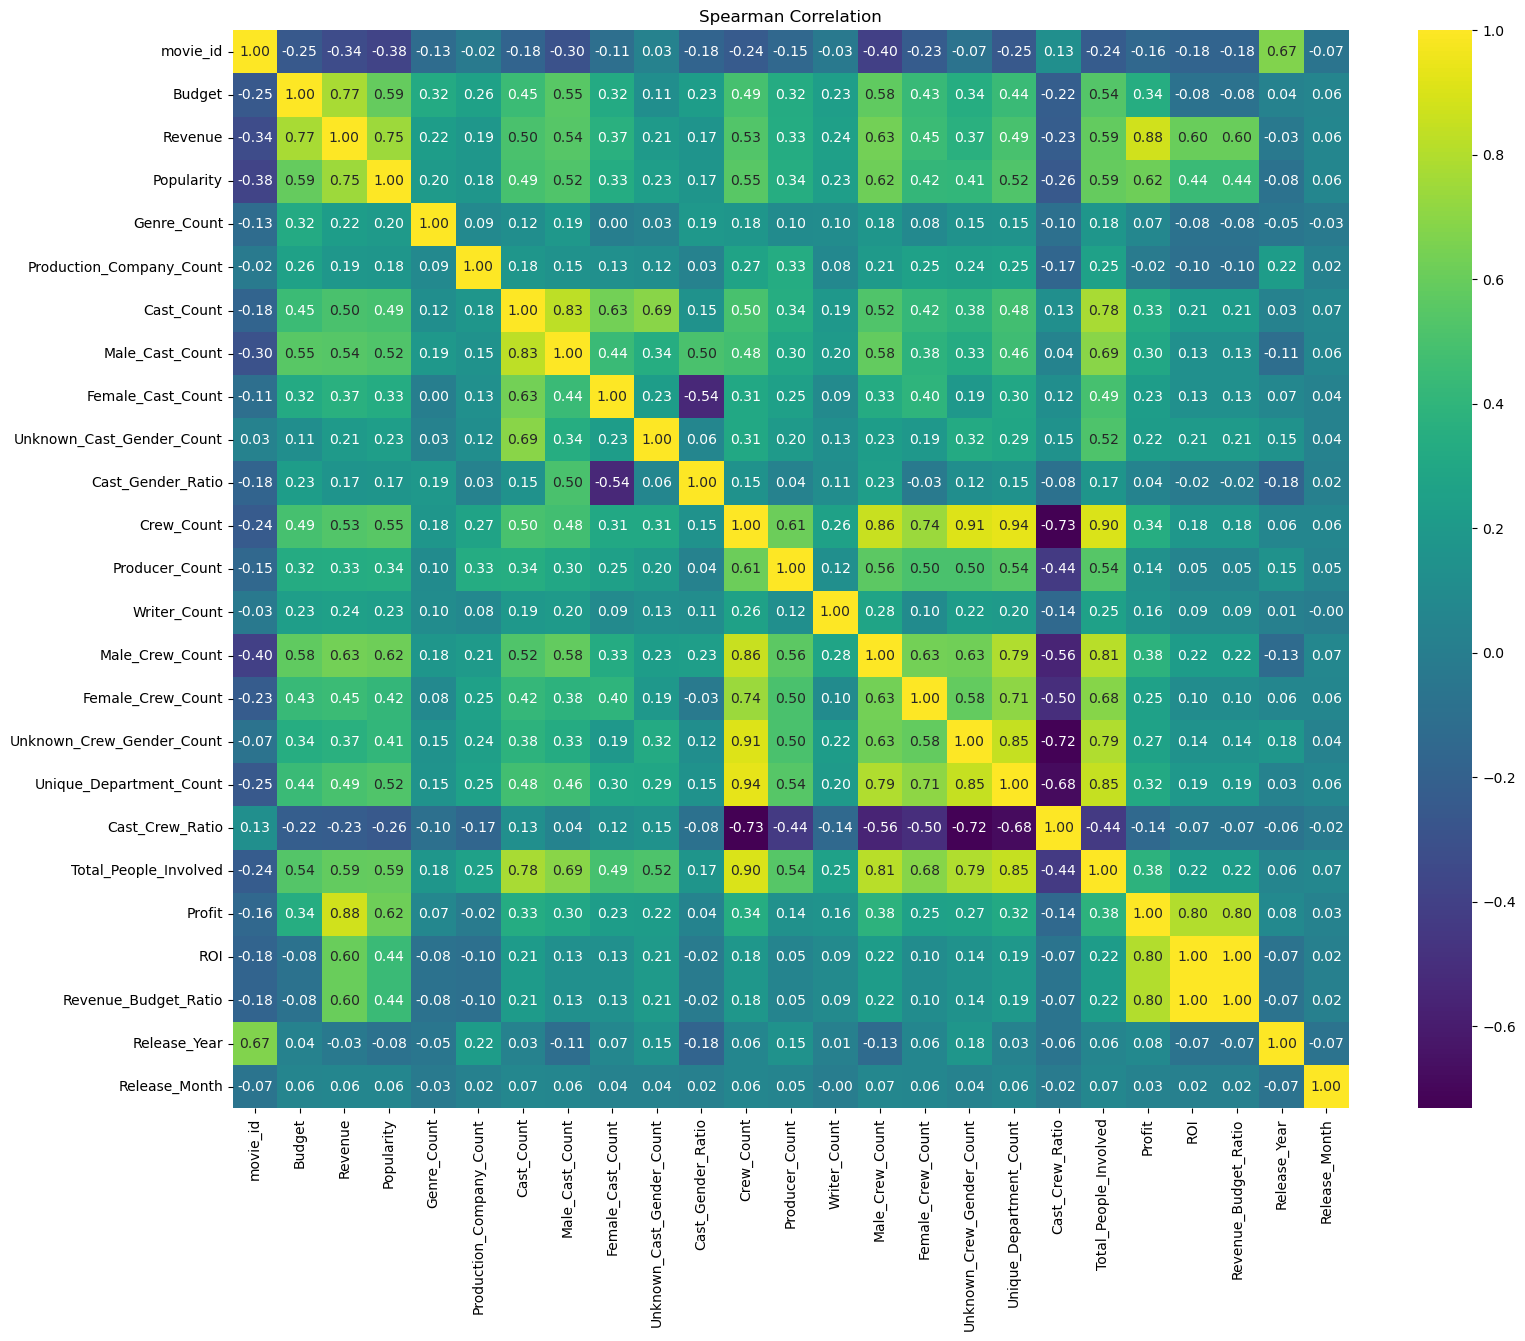

In [10]:
plt.figure(figsize=(18,14))

sns.heatmap(
    spearman,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Spearman Correlation")
plt.show()

#### Category Distribution

In [11]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n", "="*60)
    print(col)
    print("="*60)
    print(df[col].value_counts().head(10))


title
title
The Host                                  2
Batman                                    2
Out of the Blue                           2
Avatar                                    1
The Girl on the Train                     1
Polisse                                   1
Beneath Hill 60                           1
The I Inside                              1
Ultramarines: A Warhammer 40,000 Movie    1
Crocodile Dundee                          1
Name: count, dtype: int64

Genres
Genres
Drama                     310
Comedy                    209
Drama, Romance            165
Comedy, Romance           161
Comedy, Drama             143
Comedy, Drama, Romance    101
Horror                     72
Horror, Thriller           71
Documentary                61
Drama, Comedy              58
Name: count, dtype: int64

Primary_Genre
Primary_Genre
Drama              1175
Comedy             1061
Action              636
Horror              334
Adventure           317
Thriller            204
Crime  

#### Outlier Detection (IQR)

In [12]:
for col in numeric_df.columns:

    q1 = numeric_df[col].quantile(0.25)
    q3 = numeric_df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((numeric_df[col] < lower) | (numeric_df[col] > upper)).sum()

    print(f"{col} : {outliers}")

movie_id : 704
Budget : 338
Revenue : 453
Popularity : 342
Genre_Count : 188
Production_Company_Count : 167
Cast_Count : 410
Male_Cast_Count : 223
Female_Cast_Count : 241
Unknown_Cast_Gender_Count : 404
Cast_Gender_Ratio : 321
Crew_Count : 502
Producer_Count : 102
Writer_Count : 206
Male_Crew_Count : 142
Female_Crew_Count : 71
Unknown_Crew_Gender_Count : 604
Unique_Department_Count : 0
Cast_Crew_Ratio : 452
Total_People_Involved : 334
Profit : 391
ROI : 353
Revenue_Budget_Ratio : 353
Release_Year : 273
Release_Month : 0


#### Business Rule Validation

In [13]:
print("Negative Budget :", (df["Budget"] < 0).sum())

print("Negative Revenue :", (df["Revenue"] < 0).sum())

print("Negative Popularity :", (df["Popularity"] < 0).sum())

print("Revenue < Budget :", (df["Revenue"] < df["Budget"]).sum())

print("ROI > 1000 :", (df["ROI"] > 1000).sum())

print("ROI < -100 :", (df["ROI"] < -100).sum())

Negative Budget : 0
Negative Revenue : 0
Negative Popularity : 0
Revenue < Budget : 1369
ROI > 1000 : 280
ROI < -100 : 0


#### Release Year Trend

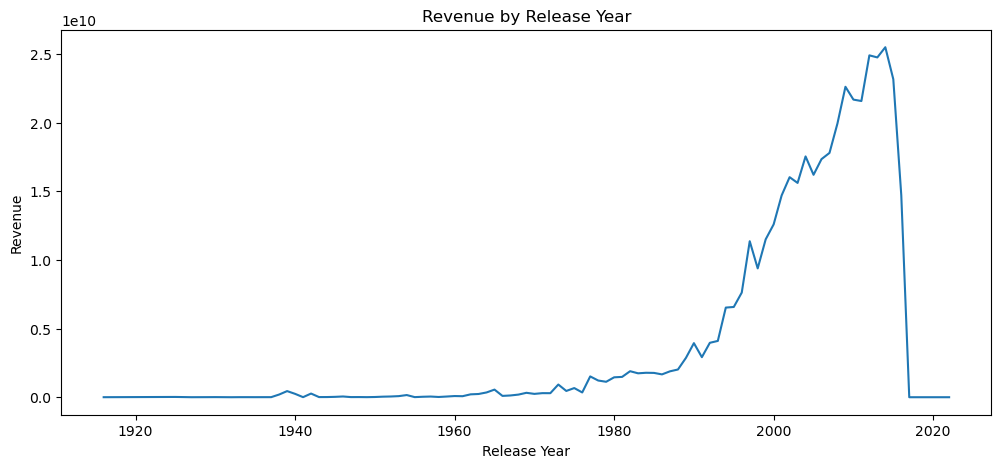

In [14]:
year = df.groupby("Release_Year")["Revenue"].sum()

year.plot(figsize=(12,5))

plt.title("Revenue by Release Year")

plt.xlabel("Release Year")

plt.ylabel("Revenue")

plt.show()

#### Release Season Trend

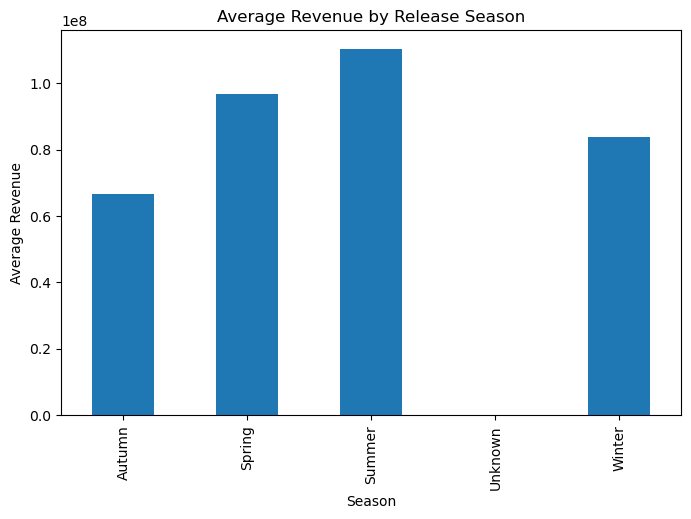

In [15]:
season = df.groupby("Release_Season")["Revenue"].mean()

season.plot(kind="bar", figsize=(8,5))

plt.title("Average Revenue by Release Season")

plt.xlabel("Season")

plt.ylabel("Average Revenue")

plt.show()

#### Dataset Quality Summary

In [16]:
print("Rows :", len(df))

print("Columns :", len(df.columns))

print("Missing Values :", df.isnull().sum().sum())

print("Duplicate Rows :", df.duplicated().sum())

print("Numeric Columns :", len(df.select_dtypes(include="number").columns))

print("Categorical Columns :", len(df.select_dtypes(include="object").columns))

Rows : 4803
Columns : 51
Missing Values : 3292
Duplicate Rows : 0
Numeric Columns : 25
Categorical Columns : 20


#### Numerical Distributions

NUMERICAL DISTRIBUTION SUMMARY
                           Count         Mean       Median        Mode  \
movie_id                    4803     57165.48     14629.00        5.00   
Budget                      4795  30494635.77  16000000.00        0.00   
Revenue                     4795  88484749.43  27645491.00        0.00   
Popularity                  4795         4.25         2.92        1.34   
Genre_Count                 4803         2.57         3.00        3.00   
Production_Company_Count    4803         3.21         3.00        2.00   
Cast_Count                  4803        22.12        16.00       15.00   
Male_Cast_Count             4803        10.05         8.00        6.00   
Female_Cast_Count           4803         5.03         4.00        3.00   
Unknown_Cast_Gender_Count   4803         7.04         4.00        1.00   
Cast_Gender_Ratio           4496         2.86         2.00        1.00   
Crew_Count                  4803        26.98        16.00        2.00   
Produce

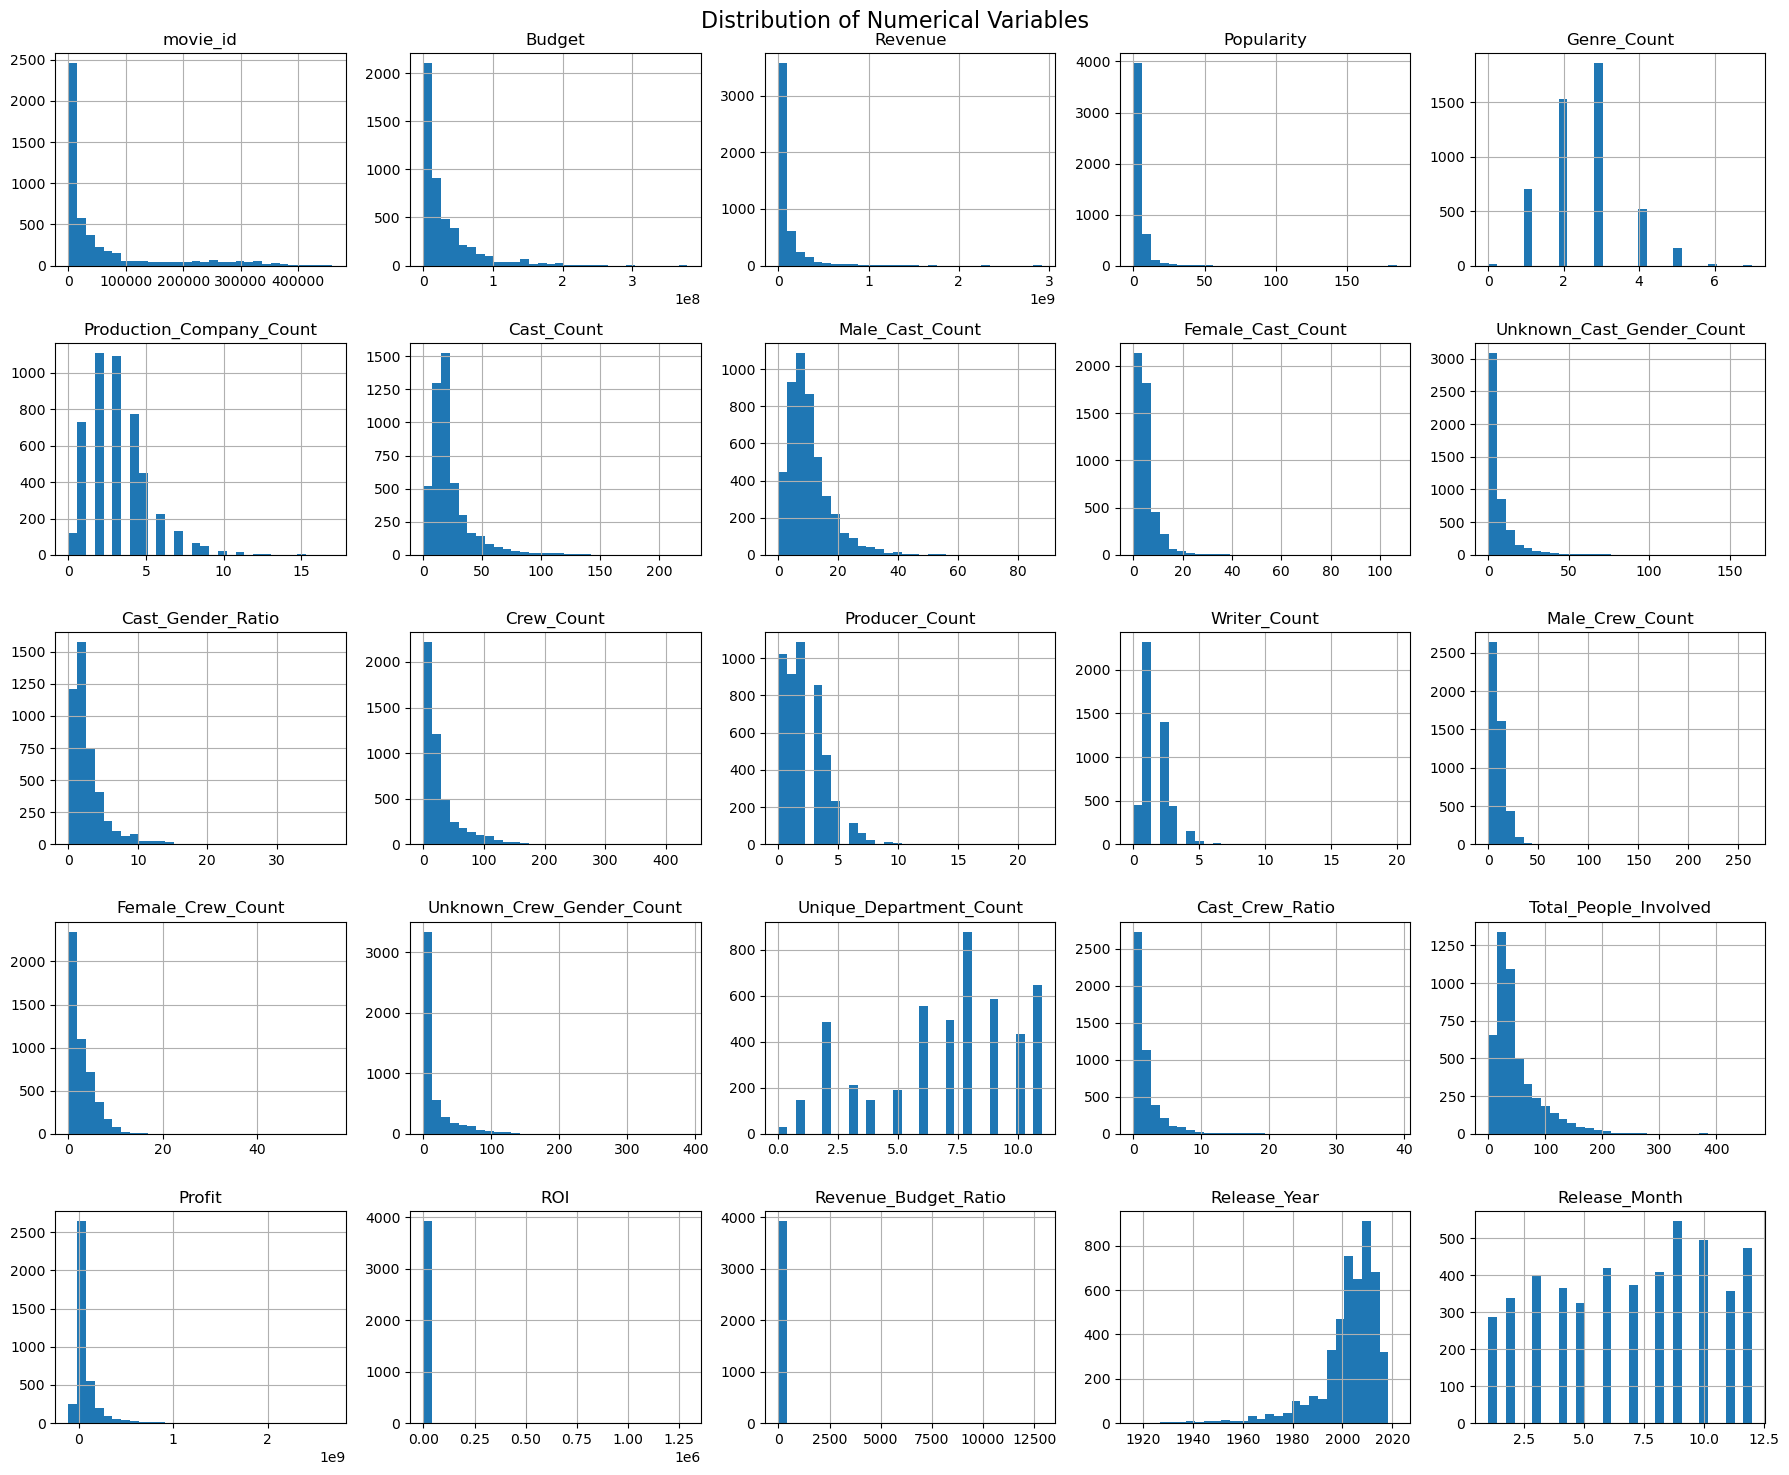

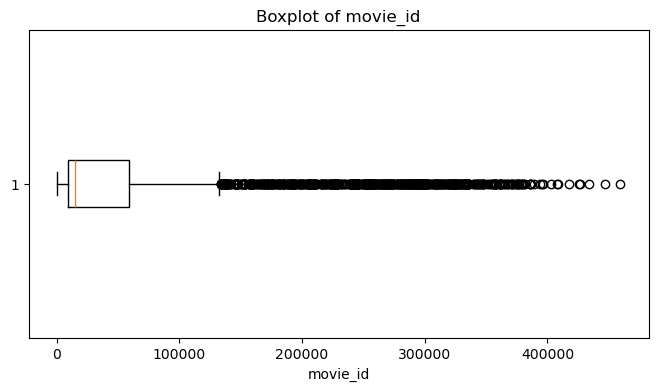

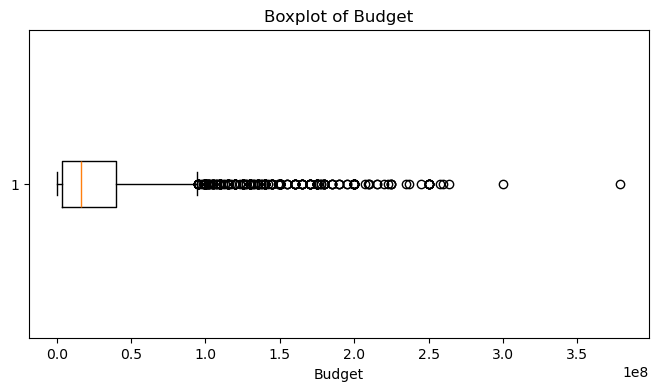

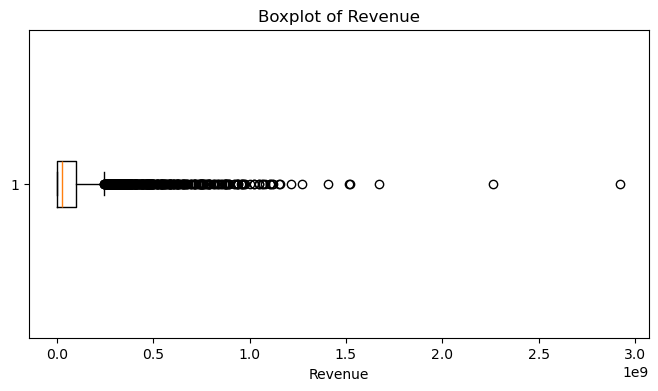

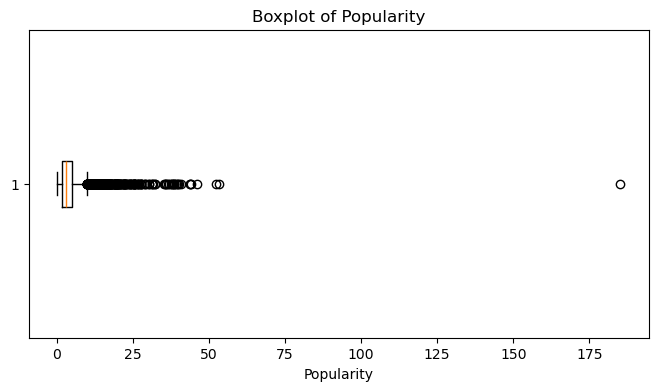

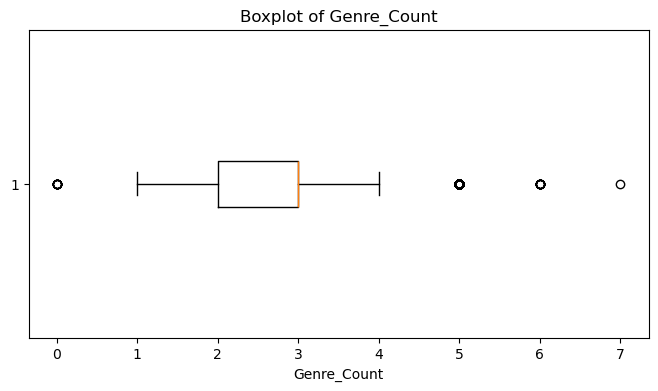

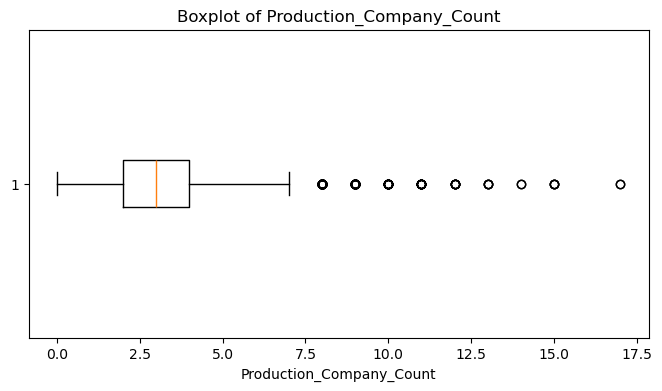

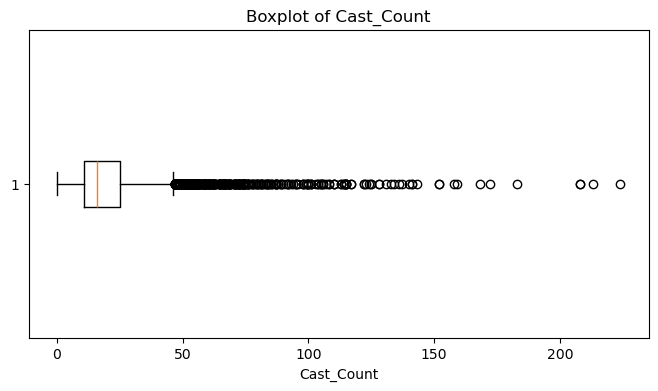

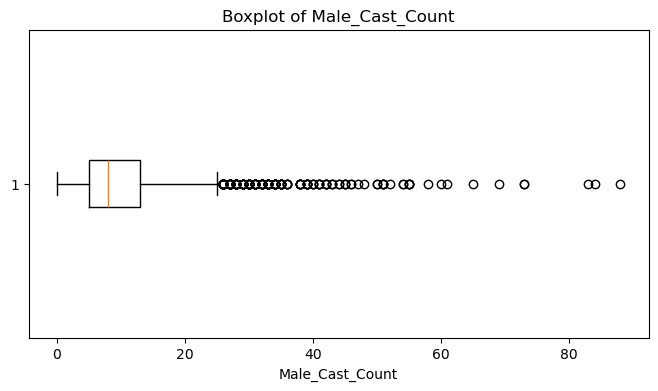

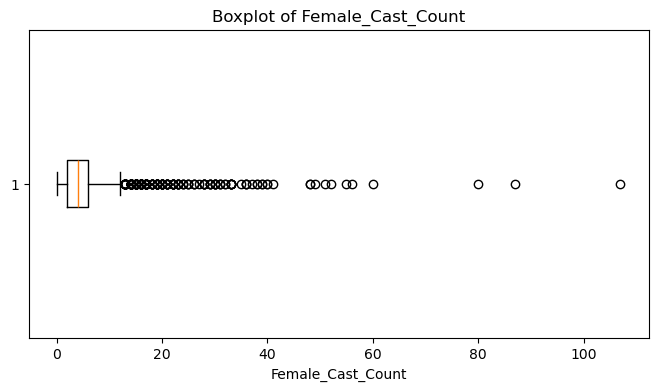

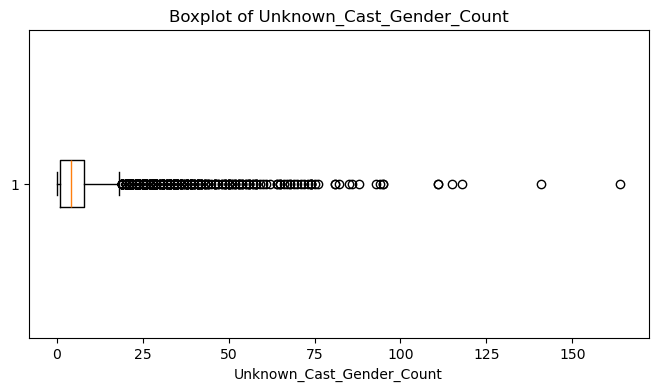

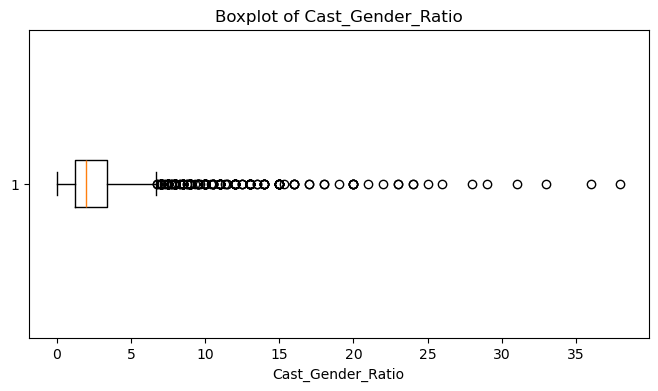

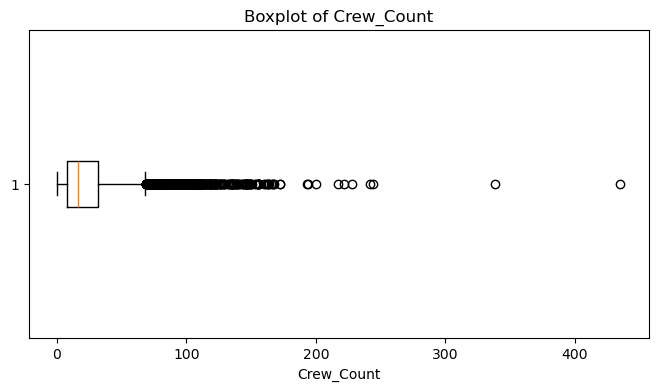

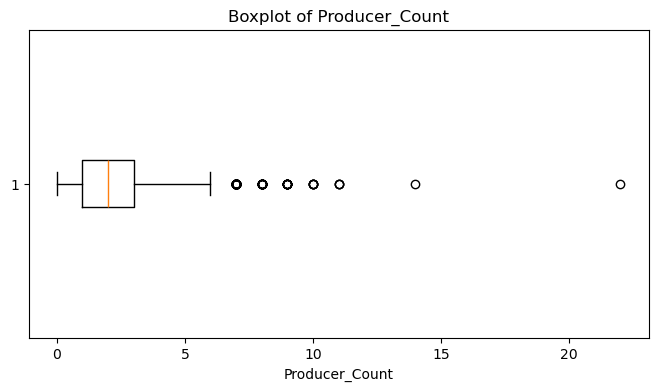

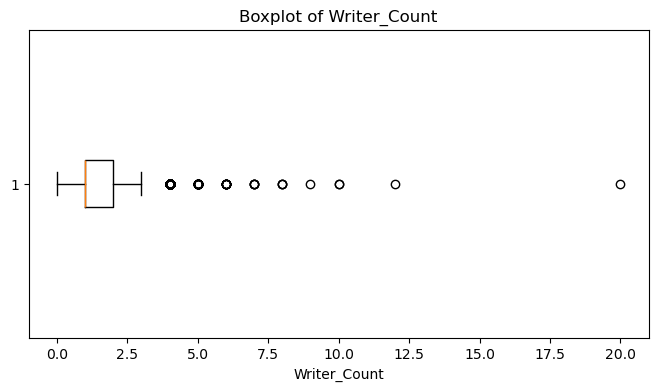

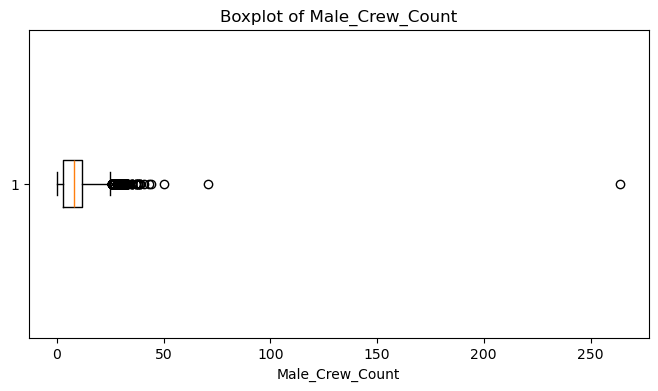

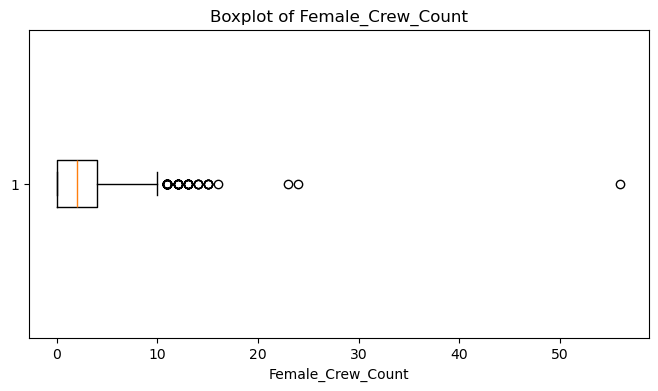

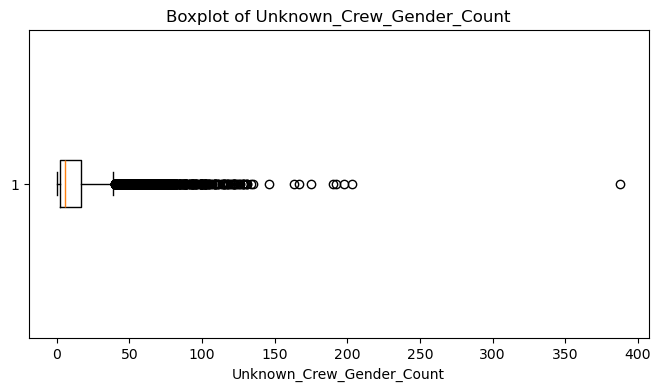

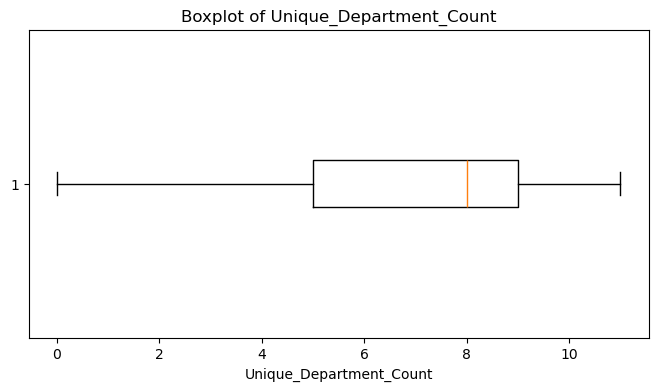

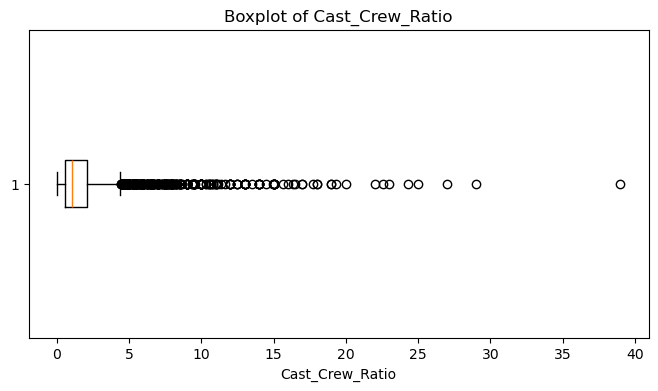

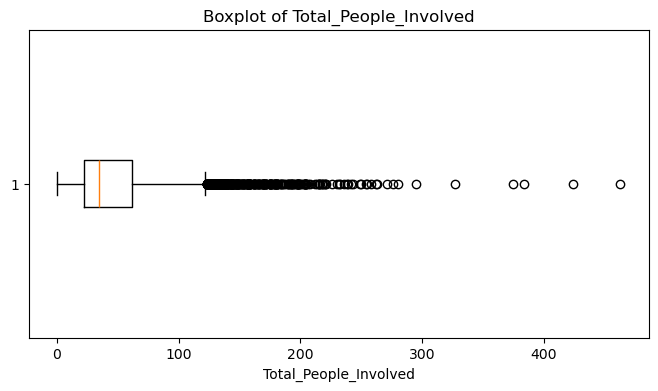

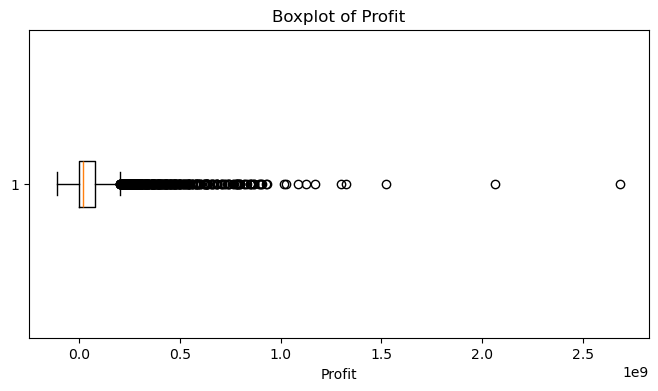

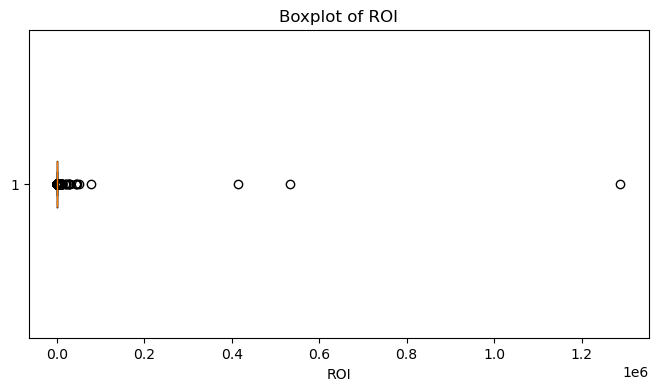

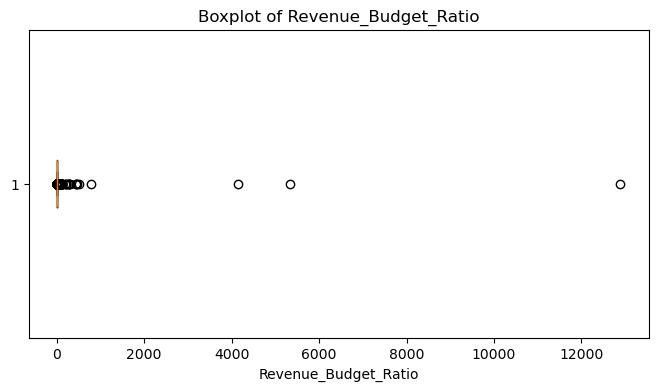

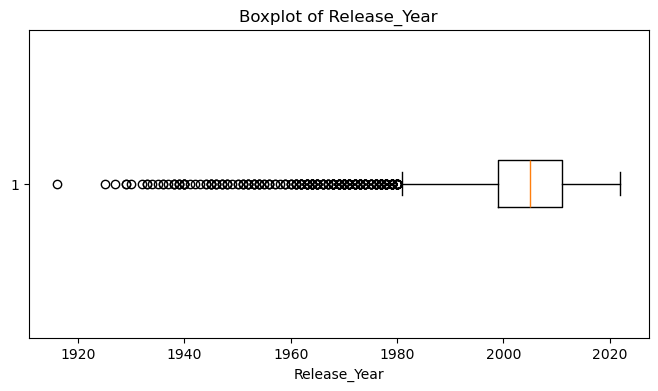

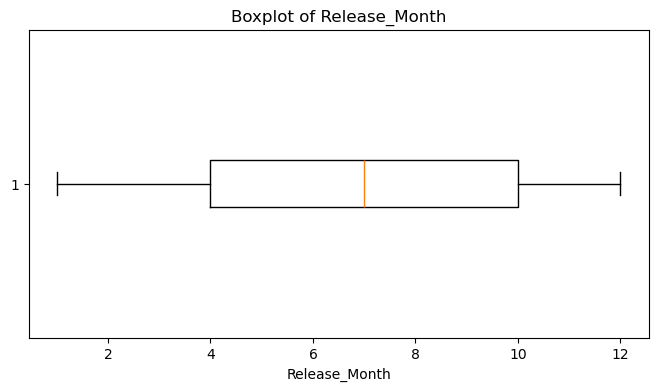

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("project_dataset.csv")

# Select Numerical Columns
numeric_df = df.select_dtypes(include=np.number)

# ==========================================
# Numerical Distribution Summary
# ==========================================

summary = pd.DataFrame({
    "Count": numeric_df.count(),
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Mode": numeric_df.mode().iloc[0],
    "Minimum": numeric_df.min(),
    "Maximum": numeric_df.max(),
    "Range": numeric_df.max() - numeric_df.min(),
    "Variance": numeric_df.var(),
    "Standard Deviation": numeric_df.std(),
    "Skewness": numeric_df.skew(),
    "Kurtosis": numeric_df.kurt(),
    "Missing Values": numeric_df.isnull().sum()
})

print("="*100)
print("NUMERICAL DISTRIBUTION SUMMARY")
print("="*100)
print(summary.round(2))

# ==========================================
# Histograms
# ==========================================

numeric_df.hist(figsize=(18,15), bins=30)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)

plt.tight_layout()

plt.show()

# ==========================================
# Boxplots
# ==========================================

for column in numeric_df.columns:
    plt.figure(figsize=(8,4))
    plt.boxplot(numeric_df[column].dropna(), vert=False)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()


PRIMARY_GENRE DISTRIBUTION
                 Count  Percentage (%)
Primary_Genre                         
Drama             1175           24.46
Comedy            1061           22.09
Action             636           13.24
Horror             334            6.95
Adventure          317            6.60
Thriller           204            4.25
Crime              202            4.21
Science Fiction    124            2.58
Animation          123            2.56
Romance            120            2.50
Fantasy            107            2.23
Family              98            2.04
Documentary         96            2.00
Mystery             47            0.98
Music               45            0.94
Western             42            0.87
War                 34            0.71
History             28            0.58
Unknown             10            0.21

PRIMARY_PRODUCTION_COMPANY DISTRIBUTION
                              Count  Percentage (%)
Primary_Production_Company                         
Paramoun

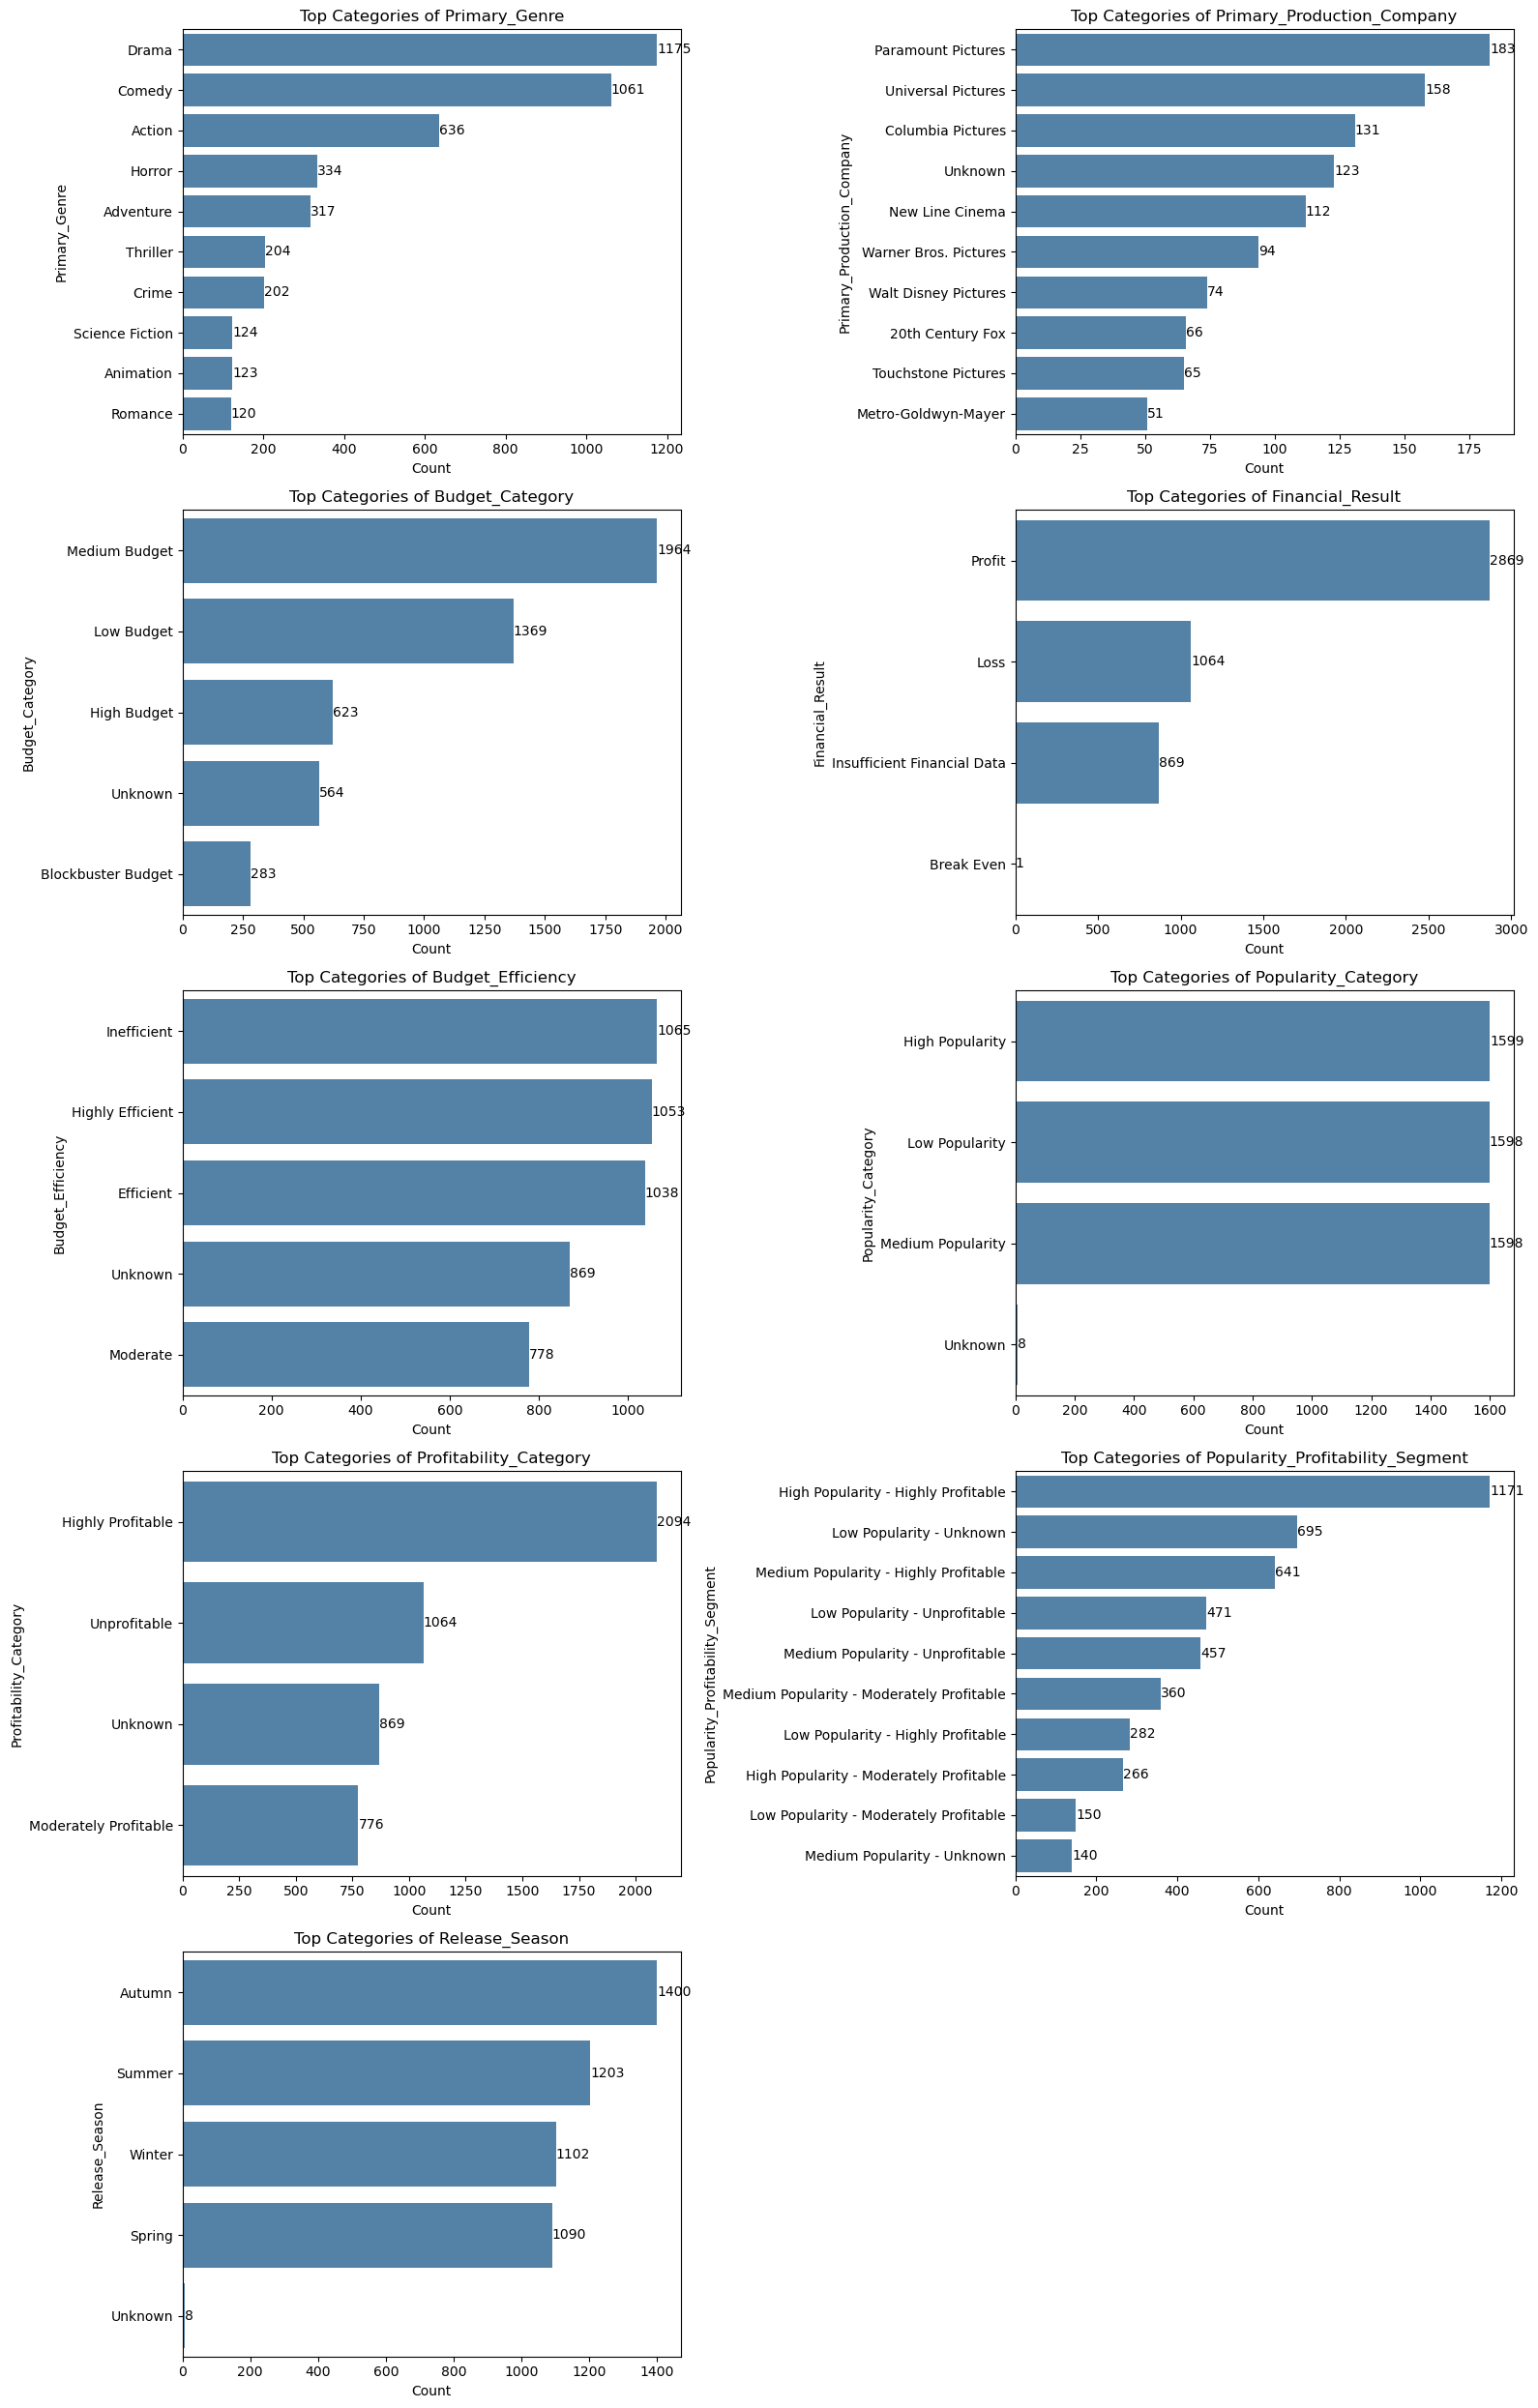

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("project_dataset.csv")

# Business-related categorical columns
categorical_cols = [
    "Primary_Genre",
    "Primary_Production_Company",
    "Budget_Category",
    "Financial_Result",
    "Budget_Efficiency",
    "Popularity_Category",
    "Profitability_Category",
    "Popularity_Profitability_Segment",
    "Release_Season"
]

# Keep only existing columns
categorical_cols = [col for col in categorical_cols if col in df.columns]

# ==========================================
# Category Distribution Summary
# ==========================================

for col in categorical_cols:

    print("\n" + "="*100)
    print(f"{col.upper()} DISTRIBUTION")
    print("="*100)

    summary = pd.DataFrame({
        "Count": df[col].fillna("Missing").value_counts(),
        "Percentage (%)": round(df[col].fillna("Missing").value_counts(normalize=True) * 100, 2)
    })

    print(summary)

# ==========================================
# Top 10 Category Plots
# ==========================================

rows = (len(categorical_cols) + 1) // 2

fig, axes = plt.subplots(rows, 2, figsize=(16, rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    top10 = df[col].fillna("Missing").value_counts().head(10)

    sns.barplot(
        x=top10.values,
        y=top10.index,
        color="steelblue",
        ax=axes[i]
    )

    axes[i].set_title(f"Top Categories of {col}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel(col)

    # Display count on bars
    for container in axes[i].containers:
        axes[i].bar_label(container)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()